# Paso 0: Exploración Inicial y Alertas Críticas de Calidad de Datos

Introducción Práctica

Antes de tocar o limpiar cualquier dato, el primer paso de todo científico de datos es realizar un diagnóstico de calidad (Data Quality Assessment). En este bloque vamos a cargar el dataset masivo y programar el software para que audite de forma automática la presencia de valores faltantes y registros duplicados, arrojando alertas críticas en la consola si los umbrales superan lo aceptable para el negocio.

In [ ]:
#datos.gob.ar/dataset/turismo-conectividad-aerea (base_microdatos.csv)
import pandas as pd
import numpy as np

print("--- INICIANDO AUDITORÍA Y EXPLORACIÓN DE DATOS ---")

# 1. Carga del dataset de microdatos de conectividad aérea
base = pd.read_csv('base_microdatos.csv')
print(f"✅ Dataset cargado correctamente.")
print(f"   • Cantidad total de registros (filas): {base.shape[0]:,}")
print(f"   • Cantidad de variables (columnas): {base.shape[1]}")

print("\n--- DETECCIÓN AUTOMÁTICA DE ALERTAS CRÍTICAS ---")

# Creamos una lista vacía para almacenar las columnas con problemas críticos de forma dinámica
columnas_criticas_detectadas = []

# 2. Análisis de Valores Nulos
nulos_por_columna = base.isnull().sum()
columnas_con_nulos = nulos_por_columna[nulos_por_columna > 0]

if not columnas_con_nulos.empty:
    for col, cantidad in columnas_con_nulos.items():
        porcentaje = (cantidad / len(base)) * 100

        # Condición: Si faltan más de 50.000 datos, es una Alerta Crítica
        if cantidad > 50000:
            print(f"🚨 ALERTA CRÍTICA: La columna '{col}' presenta {cantidad:,} valores faltantes ({porcentaje:.1f}% del total).")
            # El software "descubre" la columna problema y la guarda en nuestra lista
            columnas_criticas_detectadas.append(col)
        else:
            print(f"⚠️ ADVERTENCIA: La columna '{col}' presenta {cantidad:,} valores faltantes ({porcentaje:.2f}% del total).")
else:
    print("👍 Excelente: No se detectaron valores faltantes en ninguna columna.")

# 3. Análisis de Duplicados
duplicados_totales = base.duplicated().sum()
if duplicados_totales > 0:
    print(f"⚠️ ADVERTENCIA: Se detectaron {duplicados_totales} registros exactamente duplicados en la base.")
else:
    print("👍 Excelente: No se detectaron registros duplicados.")


# ==========================================
# CONCLUSIÓN AUTOMATIZADA DE EXPLORACIÓN (DINÁMICA)
# ==========================================
print("\n=== DIAGNÓSTICO INICIAL DEL ANALISTA ===")

if len(columnas_criticas_detectadas) > 0:
    print("El software ha identificado de forma autónoma un problema severo de calidad de datos.")
    print("Las dimensiones críticas que ponen en riesgo el análisis son:")

    # Recorremos la lista
    for col_problema in columnas_criticas_detectadas:
        total_nulos = base[col_problema].isnull().sum()
        print(f" -> '{col_problema}' con un bache de {total_nulos:,} registros vacíos.")

    print("\n🤔 PREGUNTA PARA LA CLASE: ¿Debemos borrar estas filas detectadas? ¿Es un error del sistema?")
    print("👉 PRÓXIMO PASO: Ejecutar el 'Bloque 1: Limpieza e Integración' para cruzar estas variables con 'origen_pais' y deducir la causa raíz.")
else:
    print("👉 DIAGNÓSTICO: La base de datos no presenta anomalías estructurales masivas. Se puede proceder directo al análisis estadístico.")

--- INICIANDO AUDITORÍA Y EXPLORACIÓN DE DATOS ---
✅ Dataset cargado correctamente.
   • Cantidad total de registros (filas): 1,048,043
   • Cantidad de variables (columnas): 19

--- DETECCIÓN AUTOMÁTICA DE ALERTAS CRÍTICAS ---
🚨 ALERTA CRÍTICA: La columna 'origen_provincia' presenta 224,794 valores faltantes (21.4% del total).
⚠️ ADVERTENCIA: La columna 'origen_continente' presenta 1 valores faltantes (0.00% del total).
🚨 ALERTA CRÍTICA: La columna 'destino_provincia' presenta 226,306 valores faltantes (21.6% del total).
⚠️ ADVERTENCIA: Se detectaron 65 registros exactamente duplicados en la base.

=== DIAGNÓSTICO INICIAL DEL ANALISTA ===
El software ha identificado de forma autónoma un problema severo de calidad de datos.
Las dimensiones críticas que ponen en riesgo el análisis son:
 -> 'origen_provincia' con un bache de 224,794 registros vacíos.
 -> 'destino_provincia' con un bache de 226,306 registros vacíos.

🤔 PREGUNTA PARA LA CLASE: ¿Debemos borrar estas filas detectadas? ¿Es un

# Bloque 1: Limpieza e Integración de Datos
***Introducción Práctica***

En el mundo real, los datos nunca vienen limpios. Vienen con duplicados, valores nulos (NaN), o registros corruptos. Si alimentamos un modelo de Machine Learning o un reporte ejecutivo con datos "sucios", las conclusiones serán erróneas
(el famoso concepto Garbage In, Garbage Out).


*   Limpieza: Consiste en tomar decisiones
estratégicas sobre cómo tratar las imperfecciones. No siempre es buena idea borrar los datos faltantes; a veces es mejor "imputarlos" (rellenarlos) usando la lógica de la distribución (la media o la mediana).

*   Integración: Es el proceso de combinar variables de distintas fuentes o generar variables derivadas (nuevas columnas calculadas a partir de las existentes) para enriquecer nuestro análisis.


# Codigo Practico
En este primer bloque nos enfrentamos a un dataset masivo de más de 1 millón de registros de vuelos en Argentina. Al realizar la exploración inicial, el software nos arroja alertas críticas: existen más de 220.000 valores faltantes en las columnas de provincias (origen_provincia y destino_provincia).

Un analista junior podría cometer el error de borrar esas filas. Sin embargo, mediante un análisis de negocio cruzado, el programa nos va a demostrar que esos nulos tienen una causa lógica: corresponden a vuelos internacionales que, por ende, no registran una provincia argentina. El código resolverá los duplicados, imputará los nulos de manera estratégica según el contexto y creará una variable derivada de negocio (vuelo_escala) para clasificar la densidad de pasajeros.

In [9]:
import pandas as pd
import numpy as np

# --- CODIGO DE DIAGNÓSTICO Y DEDUCCIÓN ---
nulos_origen = base['origen_provincia'].isnull().sum()
vuelos_internacionales = base[base['origen_pais'] != 'Argentina'].shape[0]

print("=== DEDUCCIÓN DEL ANALISTA ===")
print(f"1. Total de filas sin provincia de origen: {nulos_origen}")
print(f"2. Total de vuelos cuyo país de origen NO es Argentina: {vuelos_internacionales}")

if abs(nulos_origen - vuelos_internacionales) < 100: # Margen por posibles errores de carga
    print("👉 CONCLUSIÓN: Se deduce y confirma que los valores nulos en 'provincia' corresponden a vuelos internacionales. Por ende, no es un error de carga; es una característica del negocio. Se procede a etiquetar como 'No Aplica / Internacional'.")
else:
    print("👉 CONCLUSIÓN: Los nulos no coinciden exactamente con los vuelos internacionales. Requiere revisión mixta.")

# A. Limpieza: Eliminamos duplicados usando .copy()
base_clean = base.drop_duplicates().copy()
print(f"Cantidad de registros duplicados eliminados: {base.shape[0] - base_clean.shape[0]}")

# B. Imputación inteligente de nulos sin romper la indexación
for col in base_clean.columns:
    if base_clean[col].dtype == 'object':
        # Para evitar cambiar provincias internacionales por la moda,
        # rellenamos explícitamente con 'No Aplica / Internacional'
        if 'provincia' in col:
            base_clean[col] = base_clean[col].fillna('No Aplica / Internacional')
        else:
            moda = base_clean[col].mode()[0] if not base_clean[col].mode().empty else 'Desconocido'
            base_clean[col] = base_clean[col].fillna(moda)
    else:
        mediana = base_clean[col].median()
        base_clean[col] = base_clean[col].fillna(mediana)

print("\n--- Comprobación de Nulos Post-Limpieza ---")
print(base_clean[['origen_provincia', 'destino_provincia']].isnull().sum())

# C. Integración: Creación de variable derivada (Clasificación de Escala)
base_clean['vuelo_escala'] = pd.cut(
    base_clean['pasajeros'],
    bins=[-float('inf'), 50, 150, float('inf')],
    labels=['Cabotaje Pequeño / Regional', 'Mediano', 'Alta Densidad']
)

print("\n--- Distribución de la nueva variable de Integración ---")
print(base_clean['vuelo_escala'].value_counts())




=== DEDUCCIÓN DEL ANALISTA ===
1. Total de filas sin provincia de origen: 224794
2. Total de vuelos cuyo país de origen NO es Argentina: 224794
👉 CONCLUSIÓN: Se deduce y confirma que los valores nulos en 'provincia' corresponden a vuelos internacionales. Por ende, no es un error de carga; es una característica del negocio. Se procede a etiquetar como 'No Aplica / Internacional'.
Cantidad de registros duplicados eliminados: 65

--- Comprobación de Nulos Post-Limpieza ---
origen_provincia     0
destino_provincia    0
dtype: int64

--- Distribución de la nueva variable de Integración ---
vuelo_escala
Alta Densidad                  584643
Mediano                        399954
Cabotaje Pequeño / Regional     63381
Name: count, dtype: int64


¿En qué se aplica?

* Detección de fraudes: Identificar registros duplicados sospechosos o transacciones con campos vacíos.

* Segmentación de marketing: La integración (como crear balance_category) permite al equipo de marketing no hablarle a un número abstracto (ej: $1250), sino a un segmento de clientes de "Saldo Medio", personalizando las campañas de correo o promociones.

# Bloque 2: Medidas de Tendencia Central y Dispersión


Introducción Práctica
Para entender un volumen masivo de datos, necesitamos resumirlo en pocos números orientativos.
  

* Tendencia Central: ¿Dónde está el "centro" de los datos? La Media es el promedio tradicional, pero es peligrosamente sensible a los extremos (si vos ganás $10 y yo $90, el promedio dice que ambos ganamos $50, lo cual es engañoso). La Mediana corta los datos a la mitad (50% arriba, 50% abajo) y la Moda es lo más repetido.



*  Dispersión: ¿Qué tan alejados del centro están los datos? La Desviación Estándar nos dice qué tanto varían los saldos respecto al promedio. El IQR (Rango Intercuartílico) mide la distancia entre el percentil 25 y el 75, dándonos el tamaño de la "caja" donde se concentra el 50% central de los clientes.
n
# Practica

Con más de un millón de registros, no podemos sacar conclusiones mirando la tabla a simple vista. Necesitamos métricas descriptivas que resuman el comportamiento del mercado aeronáutico. Evaluaremos cuántos pasajeros se transportan en promedio por registro y qué tan disperso es ese número.

Al comparar analíticamente la media y la mediana, el código nos permitirá deducir si el mercado está concentrado en unos pocos vuelos masivos o si es homogéneo. El IQR (Rango Intercuartílico) nos mostrará los límites donde se concentra el 50% central de la operación del país.



--- EJECUTANDO ANÁLISIS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Métricas Calculadas:
  • Promedio (Media): 216.1 pasajeros por registro.
  • Centro Real (Mediana): 161.0 pasajeros por registro.
  • Desviación Estándar (std): 178.1
  • 50% Central de los Vuelos (IQR): Transportan entre 96 y 273 pasajeros.

=== DEDUCCIÓN DEL ANALISTA ===
Diferencia (Media - Mediana): 55.1
👉 CONCLUSIÓN: Deducimos que la distribución de pasajeros está fuertemente sesgada a la derecha.
   Esto demuestra que la gran mayoría de las operaciones aéreas registradas corresponden a vuelos regionales,
   conexiones secundarias o aviones de menor porte (por eso la Mediana es más baja). Sin embargo, existen
   rutas hiper-masivas troncales (ej. Aeroparque - Córdoba) con cientos de pasajeros que 'tiran' el promedio hacia arriba.


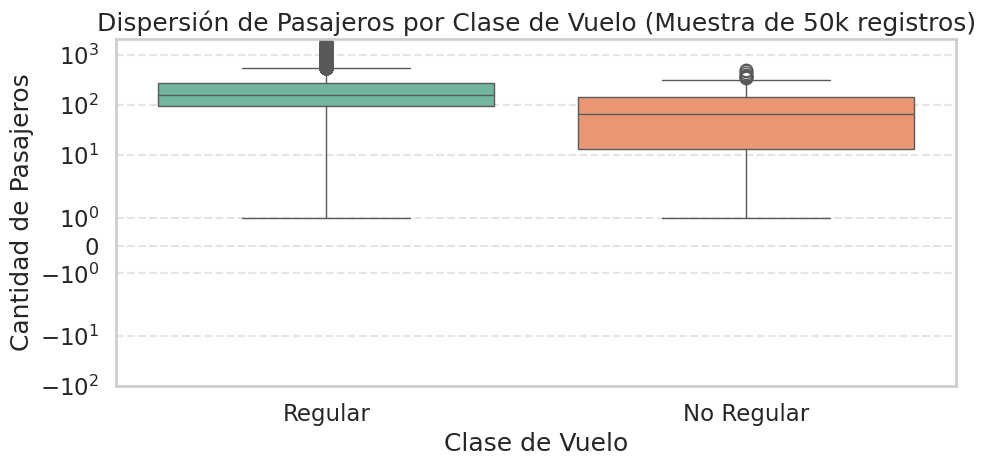

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EJECUTANDO ANÁLISIS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")

# 1. Cálculo de métricas sobre la cantidad de pasajeros
media_pax = base_clean['pasajeros'].mean()
mediana_pax = base_clean['pasajeros'].median()
std_pax = base_clean['pasajeros'].std()

# 2. Análisis por Cuartiles y Rango Intercuartílico (IQR)
q1 = base_clean['pasajeros'].quantile(0.25)
q3 = base_clean['pasajeros'].quantile(0.75)
iqr = q3 - q1

print(f"Métricas Calculadas:")
print(f"  • Promedio (Media): {media_pax:.1f} pasajeros por registro.")
print(f"  • Centro Real (Mediana): {mediana_pax:.1f} pasajeros por registro.")
print(f"  • Desviación Estándar (std): {std_pax:.1f}")
print(f"  • 50% Central de los Vuelos (IQR): Transportan entre {q1:.0f} y {q3:.0f} pasajeros.\n")

# ==========================================
# CONCLUSIÓN AUTOMATIZADA (DEDUCCIÓN)
# ==========================================
print("=== DEDUCCIÓN DEL ANALISTA ===")
diferencia = media_pax - mediana_pax
print(f"Diferencia (Media - Mediana): {diferencia:.1f}")

if media_pax > mediana_pax:
    print("👉 CONCLUSIÓN: Deducimos que la distribución de pasajeros está fuertemente sesgada a la derecha.")
    print("   Esto demuestra que la gran mayoría de las operaciones aéreas registradas corresponden a vuelos regionales,")
    print("   conexiones secundarias o aviones de menor porte (por eso la Mediana es más baja). Sin embargo, existen")
    print("   rutas hiper-masivas troncales (ej. Aeroparque - Córdoba) con cientos de pasajeros que 'tiran' el promedio hacia arriba.")
else:
    print("👉 CONCLUSIÓN: La distribución es simétrica. El mercado opera con un volumen de pasajeros constante y homogéneo en todas sus rutas.")

# 3. Visualización de la Dispersión
plt.figure(figsize=(10, 5))


sns.boxplot(
    x='clase_vuelo',
    y='pasajeros',
    hue='clase_vuelo',
    data=base_clean.sample(50000, random_state=42),
    palette='Set2',
    legend=False
)

plt.title('Dispersión de Pasajeros por Clase de Vuelo (Muestra de 50k registros)')
plt.xlabel('Clase de Vuelo')
plt.ylabel('Cantidad de Pasajeros')
plt.yscale('symlog') # Escala logarítmica para absorber los outliers extremos sin deformar la caja
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

¿En qué se aplica?

*  Gestión de riesgos: Evaluar la dispersión del saldo ayuda al banco a entender si sus depósitos dependen de unos pocos clientes multimillonarios (alta dispersión, alto riesgo) o si están distribuidos equitativamente en la clase media (baja dispersión, menor riesgo).

*  Fijación de precios (Pricing): Analizar los percentiles de ingresos de los usuarios para definir el costo de una membresía premium.

# Bloque 3: Distribuciones y Correlación


Introducción Práctica
* Distribución: Es la "silueta" o forma que toman nuestros datos si los graficamos en un histograma. Nos permite saber si la mayoría de los clientes se agrupa en valores bajos (sesgo a la derecha) o si siguen una campana perfecta (Distribución Normal).

* Correlación: Mide el grado de asociación lineal entre dos variables numéricas. Varía entre -1 y 1.
Si da 1, cuando una variable sube, la otra también (ej: a más edad, más saldo acumulado).
Si da 0, no tienen ninguna relación.



> Nota clave: Correlación no implica causalidad. Que dos variables se muevan juntas no significa que una cause a la otra.

# Practica

La distribución nos muestra la "silueta" visual de los datos, mientras que la correlación mide el grado de asociación lineal entre las variables numéricas operativas del avión (pasajeros, asientos, vuelos).

Utilizaremos el Coeficiente de Correlación de Pearson ($r$) para deducir un factor clave del negocio: qué tan eficiente es la oferta del sector aeronáutico respecto a la demanda real.

--- EJECUTANDO ANÁLISIS DE DISTRIBUCIONES Y CORRELACIÓN ---


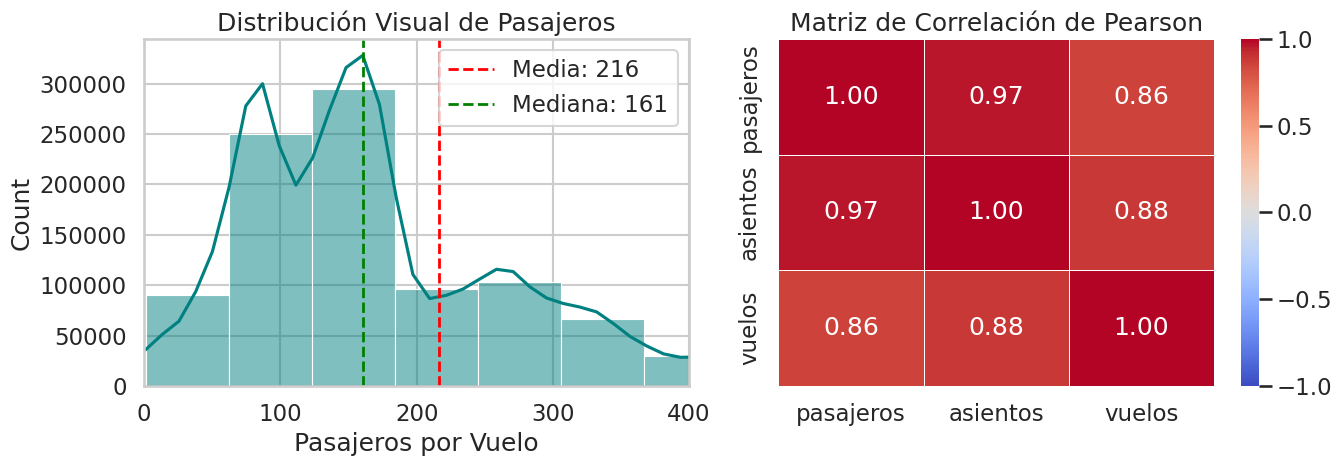


=== DEDUCCIÓN DEL ANALISTA ===
Coeficiente r entre Pasajeros y Asientos: 0.9663
👉 CONCLUSIÓN: Se detecta una relación lineal positiva casi perfecta.
   Deducción de negocio: Las aerolíneas operan con una alta eficiencia de asignación de activos de capital.
   A mayor volumen de pasajeros esperado en la ruta, se incrementa de forma milimétrica la capacidad del avión (asientos).
   Esto descarta ineficiencias sistemáticas severas como el envío constante de aviones grandes a rutas inactivas.


In [22]:
print("--- EJECUTANDO ANÁLISIS DE DISTRIBUCIONES Y CORRELACIÓN ---")

# 1. Gráficos base: Histograma y Matriz de Correlación
plt.figure(figsize=(14, 5))

# Subplot 1: Histograma de Distribución
plt.subplot(1, 2, 1)
sns.histplot(base_clean['pasajeros'], kde=True, bins=40, color='teal')
plt.axvline(media_pax, color='red', linestyle='--', linewidth=2, label=f'Media: {media_pax:.0f}')
plt.axvline(mediana_pax, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana_pax:.0f}')
plt.title('Distribución Visual de Pasajeros')
plt.xlabel('Pasajeros por Vuelo')
plt.xlim(0, 400) # Acotamos la vista para apreciar la densidad principal
plt.legend()

# Subplot 2: Heatmap de Correlación
plt.subplot(1, 2, 2)
columnas_numericas = base_clean[['pasajeros', 'asientos', 'vuelos']]
matriz_corr = columnas_numericas.corr()
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Matriz de Correlación de Pearson')

plt.tight_layout()
plt.show()

# ==========================================
# CONCLUSIÓN AUTOMATIZADA (DEDUCCIÓN)
# ==========================================
corr_pax_asientos = matriz_corr.loc['pasajeros', 'asientos']
print("\n=== DEDUCCIÓN DEL ANALISTA ===")
print(f"Coeficiente r entre Pasajeros y Asientos: {corr_pax_asientos:.4f}")

if corr_pax_asientos > 0.90:
    print("👉 CONCLUSIÓN: Se detecta una relación lineal positiva casi perfecta.")
    print("   Deducción de negocio: Las aerolíneas operan con una alta eficiencia de asignación de activos de capital.")
    print("   A mayor volumen de pasajeros esperado en la ruta, se incrementa de forma milimétrica la capacidad del avión (asientos).")
    print("   Esto descarta ineficiencias sistemáticas severas como el envío constante de aviones grandes a rutas inactivas.")
else:
    print("👉 CONCLUSIÓN: Correlación moderada o baja. Existe un desacople importante entre la oferta de asientos y la demanda real de pasajeros.")

¿En qué se aplica?

* Modelos predictivos de scoring crediticio: Si descubrimos que la edad y el historial de deudas están altamente correlacionados con el impago, esas variables se vuelven cruciales para el algoritmo que aprueba o rechaza tarjetas de crédito.

* Análisis de comportamiento: Ver la distribución de llamadas o interacciones de los clientes para dimensionar las áreas de atención al cliente (Call Center).

# 4. Transformación de Datos y Reducción de Dimensionalidad

Introducción Práctica
* Para preparar los datos para analítica avanzada o algoritmos matemáticos complejos, debemos resolver dos problemas: las variables de texto no se pueden operar directamente y las numéricas tienen diferentes magnitudes.

* Aplicaremos LabelEncoder para transformar categorías clave en enteros identificables y StandardScaler para estandarizar la escala. Finalmente, correremos PCA (Análisis de Componentes Principales) para comprimir la varianza de múltiples características operativas en sólo dos dimensiones conceptuales, demostrando si somos capaces de simplificar la estructura del dataset sin perder información valiosa.


--- EJECUTANDO PREPROCESAMIENTO Y REDUCCIÓN DE DIMENSIONALIDAD (PCA) ---
Métricas del Modelo PCA:
  • Varianza explicada por Componente 1 (PC1): 56.4%
  • Varianza explicada por Componente 2 (PC2): 20.8%
  • Información total retenida (Suma de varianza): 77.2%

=== DEDUCCIÓN DEL ANALISTA ===
👉 CONCLUSIÓN: ¡Éxito de reducción dimensional! Al compactar el dataset de 5 a solo 2 dimensiones,
   logramos retener el 77.2% de la variabilidad original de los datos.
   Se deduce que el gráfico bidimensional generado a continuación es estadísticamente representativo
   y confiable para estudiar clusters operativos de vuelos en el país reduciendo el costo de cómputo.


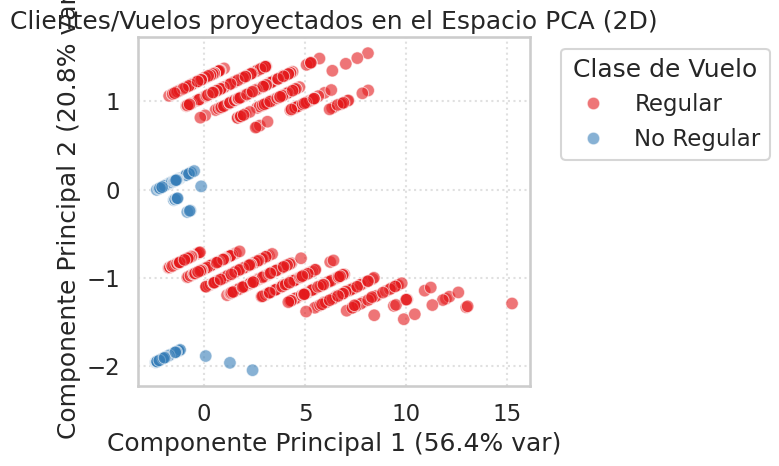

In [23]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

print("--- EJECUTANDO PREPROCESAMIENTO Y REDUCCIÓN DE DIMENSIONALIDAD (PCA) ---")

# 1. Copia y Codificación de Variables Categóricas (Texto a Números)
base_encoded = base_clean.copy()
le = LabelEncoder()
categoricas_clave = ['clasificacion_vuelo', 'clase_vuelo', 'origen_provincia', 'destino_provincia']

for col in categoricas_clave:
    base_encoded[col] = le.fit_transform(base_encoded[col].astype(str))

# 2. Selección de Features y Escalado (Obligatorio para PCA)
features_numericas = ['clasificacion_vuelo', 'clase_vuelo', 'pasajeros', 'asientos', 'vuelos']
X = base_encoded[features_numericas]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicación de PCA para reducir a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Cálculo del rendimiento de la reducción
varianza_total = pca.explained_variance_ratio_.sum() * 100

print(f"Métricas del Modelo PCA:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  • Varianza explicada por Componente {i+1} (PC{i+1}): {var*100:.1f}%")
print(f"  • Información total retenida (Suma de varianza): {varianza_total:.1f}%\n")

# ==========================================
# CONCLUSIÓN AUTOMATIZADA (DEDUCCIÓN)
# ==========================================
print("=== DEDUCCIÓN DEL ANALISTA ===")
if varianza_total >= 70:
    print(f"👉 CONCLUSIÓN: ¡Éxito de reducción dimensional! Al compactar el dataset de 5 a solo 2 dimensiones,")
    print(f"   logramos retener el {varianza_total:.1f}% de la variabilidad original de los datos.")
    print("   Se deduce que el gráfico bidimensional generado a continuación es estadísticamente representativo")
    print("   y confiable para estudiar clusters operativos de vuelos en el país reduciendo el costo de cómputo.")
else:
    print("👉 CONCLUSIÓN: La varianza retenida es inferior al umbral recomendado (70%). Dos componentes no alcanzan")
    print("   para explicar la complejidad del tráfico aéreo; se recomienda evaluar agregar un tercer componente principal (PC3).")

# 5. Visualización del espacio reducido por PCA
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['clase_vuelo_original'] = base_clean['clase_vuelo'].values

plt.figure(figsize=(8, 5))
# Graficamos una muestra de 10,000 registros para evitar congelamiento visual en entornos educativos
sns.scatterplot(
    data=df_pca.sample(10000, random_state=42),
    x='PC1', y='PC2',
    hue='clase_vuelo_original',
    alpha=0.6,
    palette='Set1'
)
plt.title('Clientes/Vuelos proyectados en el Espacio PCA (2D)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(title='Clase de Vuelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

¿En qué se aplica?

* Compresión de imágenes y reconocimiento facial: Los píxeles son miles de variables; PCA reduce las dimensiones para quedarse sólo con las facciones clave (ojos, nariz, boca).

* Sistemas de recomendación (ej. Netflix/Spotify): Agrupar miles de películas o canciones en unos pocos "ejes o componentes de gustos" para mapear qué usuarios comparten perfiles similares sin saturar los servidores.